# Notebook 05 — Comparação MLP vs. Baselines

## Contexto e conexão entre etapas

Este notebook faz parte de uma sequência de análises sobre previsão de churn:

| Notebook | Conteúdo |
|---|---|
| `02_baseline_dummy_logreg.ipynb` | DummyClassifier e Regressão Logística — baseline inicial |
| `03_mlp_pytorch.ipynb` | MLP PyTorch introdutório |
| `04_mlp_training_early_stopping.ipynb` | MLP com early stopping e logging no MLflow |
| **`05_compare_mlp_baselines.ipynb`** | **Este notebook — comparação justa entre todos os modelos** |
| `06_tradeoff_custo_fp_fn.ipynb` | Análise de custo FP vs FN e escolha do threshold de negócio |

---

## O que este notebook faz

Compara **5 modelos** usando **≥ 4 métricas** (conforme `docs/METRICAS.md`):

| Modelo | Tipo |
|---|---|
| Regressão Logística | Linear |
| Árvore de Decisão | Não-linear, interpretável |
| Random Forest | Ensemble de árvores |
| Extra Trees | Ensemble mais aleatório |
| MLP PyTorch | Rede neural do notebook 04, carregada via MLflow |

**Métricas reportadas:** PR-AUC, ROC-AUC, F1, Recall, Precision.

---

## Garantias de comparação justa

- **Mesmo CSV**: `Telco_customer_churn_ready.csv` gerado pelo EDA.
- **Mesmo SEED (42)** e mesma lógica de split 64/16/20.
- **StandardScaler** ajustado apenas no treino — sem vazamento de dados.
- Baselines e MLP avaliados no **mesmo conjunto de teste**.

## Etapa 1 — Imports, seeds e caminhos

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch  # para load_model

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)

# Seeds globais — devem coincidir com o notebook 03 para splits idênticos.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo PyTorch: {DEVICE}")

# Localiza o CSV tratado (suporta execução de dentro ou fora de ./notebooks/).
READY_PATH_CANDIDATES = [
    Path("../data/Telco_customer_churn_ready.csv"),
    Path("data/Telco_customer_churn_ready.csv"),
]
DATA_PATH = next((p for p in READY_PATH_CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, (
    "Arquivo tratado não encontrado. "
    "Execute o notebook de EDA para gerar Telco_customer_churn_ready.csv."
)
print(f"Dataset: {DATA_PATH.resolve()}")


Dispositivo PyTorch: cpu
Dataset: C:\Users\azvef\Projeto FIAP 1\9mlet-tech-challenge-1-churn-prevision\data\Telco_customer_churn_ready.csv


## Etapa 2 — Carregamento dos dados e splits

Replicamos exatamente o pré-processamento do notebook 03:
- Split estratificado 80/20 para treino+val vs teste.
- Split posterior 80/20 para separar treino de validação (usado no early stopping da MLP).
- `StandardScaler` **ajustado apenas no treino**, aplicado em val e teste.

Isso garante que todos os modelos são avaliados no **mesmo conjunto de teste**.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")

TARGET = "Churn Value"
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Split treino+val vs teste (80/20 estratificado).
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Split treino vs validação (64/16 do total).
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

# Normaliza usando apenas os parâmetros do treino.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Treino : {X_train.shape}  | Churn: {y_train.mean():.4f}")
print(f"Val    : {X_val.shape}  | Churn: {y_val.mean():.4f}")
print(f"Teste  : {X_test.shape}  | Churn: {y_test.mean():.4f}")

Shape: (7043, 1163)
Treino : (4507, 1162)  | Churn: 0.2654
Val    : (1127, 1162)  | Churn: 0.2653
Teste  : (1409, 1162)  | Churn: 0.2654


## Etapa 3 — Modelos escolhidos para comparação

Para avaliar se a MLP PyTorch realmente vale a complexidade extra, ela é comparada contra quatro modelos de famílias diferentes. A ideia é cobrir o espectro de complexidade: do mais simples ao mais sofisticado.

| Modelo | O que faz (em termos simples) | Por que incluir na comparação |
|---|---|---|
| **Regressão Logística** | Traça uma linha reta (ou hiperplano) que separa clientes que vão cancelar dos que não vão. Multiplica cada feature por um peso e soma tudo. | É o baseline "forte": rápido, interpretável e surpreendentemente competitivo. Se a MLP não bater esse, não há motivo para a complexidade extra. |
| **Árvore de Decisão** | Faz uma série de perguntas do tipo "mensalidade > R$80?" em sequência, como um fluxograma, até chegar a uma decisão. | Mostra o que acontece quando há não-linearidade mas sem regularização. Costuma overfitar — entra como "piso inferior" dos ensembles. |
| **Random Forest** | Constrói centenas de árvores de decisão, cada uma treinada em uma amostra aleatória dos dados, e faz uma votação entre elas. | Reduz o overfitting da árvore única pela média de muitas árvores. É um forte concorrente em dados tabulares e serve de referência ensemble. |
| **Extra Trees** | Igual ao Random Forest, mas os pontos de corte de cada galho também são escolhidos aleatoriamente (não só os dados). Isso injeta ainda mais diversidade. | Tende a generalizar bem e é mais rápido de treinar. Representa o "topo dos ensembles clássicos" para comparar com a rede neural. |

**MLP PyTorch** fecha o conjunto: é a única arquitetura capaz de aprender interações entre features automaticamente em múltiplas camadas, sem precisar especificá-las manualmente.


In [3]:
# Modelos sklearn — cada um representa uma família de algoritmos diferente.
# Nota: em Windows, n_jobs=-1 pode disparar BrokenProcessPool por conflito de serialização
# entre subprocessos. Mantemos n_jobs=1 para estabilidade e reprodutibilidade.
sklearn_models = {
    # Linear: aprende fronteiras lineares; rápido e interpretável.
    "LogisticRegression": LogisticRegression(
        max_iter=5000, random_state=SEED, n_jobs=1
    ),
    # Árvore única: não-linear, mas tende a overfitting sem poda.
    "DecisionTree": DecisionTreeClassifier(
        max_depth=8, random_state=SEED
    ),
    # Ensemble de árvores com bagging: reduz variância da árvore única.
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=SEED, n_jobs=1
    ),
    # Extra Trees: splits ainda mais aleatórios → mais diversidade, menor variância.
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=200, max_depth=10, random_state=SEED, n_jobs=1
    ),
}

for name, model in sklearn_models.items():
    model.fit(X_train_s, y_train)
    print(f"✓ {name} treinado")

✓ LogisticRegression treinado
✓ DecisionTree treinado
✓ RandomForest treinado
✓ ExtraTrees treinado


## Etapa 4 — MLP PyTorch (importada do notebook 04)

Carregamos a MLP já treinada no notebook 04 via MLflow.

Fluxo da busca:
1. Usa o experimento `MLP-Churn-EarlyStoppingBatching`.
2. Tenta localizar o run com nome `04_mlp_training_early_stopping`.
3. Se não achar por nome, usa o run mais recente do experimento.

> Se quiser fixar um run específico, informe `MLP_RUN_ID` manualmente na célula seguinte.

In [4]:
BATCH_SIZE = 64  # igual ao notebook 03

# --- DataLoader do conjunto de teste ---
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_test_t = to_tensor(X_test_s)
y_test_t  = to_tensor(y_test.values).unsqueeze(1)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False
)

print(f"Input dim: {X_test_s.shape[1]} | Batches de teste: {len(test_loader)}")


Input dim: 1162 | Batches de teste: 23


In [5]:
from pathlib import Path

# Resolve o banco local do MLflow de forma robusta para diferentes diretórios de execução.
MLFLOW_DB_CANDIDATES = [
    Path("mlflow.db"),
    Path("../mlflow.db"),
]
MLFLOW_DB_PATH = next((p for p in MLFLOW_DB_CANDIDATES if p.exists()), Path("mlflow.db"))
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.resolve().as_posix()}")

EXPERIMENT_NAME = "MLP-Churn-EarlyStoppingBatching"
PREFERRED_RUN_NAME = "04_mlp_training_early_stopping"

# Defina manualmente se quiser fixar um run específico.
# MLP_RUN_ID = "cole_aqui_o_run_id"
MLP_RUN_ID = None

if MLP_RUN_ID is None:
    # Tentativa 1: run com nome esperado no experimento do notebook 04.
    runs = mlflow.search_runs(
        experiment_names=[EXPERIMENT_NAME],
        filter_string=f"tags.mlflow.runName = '{PREFERRED_RUN_NAME}'",
        order_by=["start_time DESC"],
        max_results=1,
    )

    # Tentativa 2: run mais recente do experimento, mesmo sem bater nome.
    if runs.empty:
        runs = mlflow.search_runs(
            experiment_names=[EXPERIMENT_NAME],
            order_by=["start_time DESC"],
            max_results=1,
        )

    assert not runs.empty, (
        f"Nenhum run encontrado no experimento '{EXPERIMENT_NAME}'. "
        "Execute o notebook 04 antes de continuar."
    )
    MLP_RUN_ID = runs.iloc[0]["run_id"]

print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Run selecionado: {MLP_RUN_ID}")

# Carrega o modelo PyTorch serializado no artifact path 'model'.
mlp_model = mlflow.pytorch.load_model(f"runs:/{MLP_RUN_ID}/model")
mlp_model = mlp_model.to(DEVICE)
mlp_model.eval()

print("✅ Modelo MLP carregado com sucesso do MLflow.")

Tracking URI: sqlite:///C:/Users/azvef/Projeto FIAP 1/9mlet-tech-challenge-1-churn-prevision/notebooks/mlflow.db
Run selecionado: 86ec79e2703043988e6a05951766bfa4
✅ Modelo MLP carregado com sucesso do MLflow.


## Etapa 5 — Avaliação comparativa com ≥ 4 métricas

Todos os modelos são avaliados **no mesmo conjunto de teste**.

| Métrica | Por que usar |
|---|---|
| **PR-AUC** | Métrica principal em dados desbalanceados — foca na classe de churn |
| **ROC-AUC** | Capacidade discriminativa geral do modelo |
| **F1** | Equilíbrio entre precisão e recall |
| **Recall** | Proporção de churns reais identificados |
| **Precision** | Proporção de alertas que realmente são churn |

Além da comparação padrão em threshold 0.5, aplicamos **calibração de threshold para a MLP** usando o conjunto de validação. O objetivo é tornar a decisão final mais aderente ao cenário de churn sem deixar o código complexo.

In [6]:
def evaluate_sklearn(name, model, X_eval, y_eval, threshold=0.5):
    """Avalia um modelo sklearn e retorna dicionário de métricas."""
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "modelo": name,
        "pr_auc":    average_precision_score(y_eval, y_prob),
        "roc_auc":   roc_auc_score(y_eval, y_prob),
        "f1":        f1_score(y_eval, y_pred, zero_division=0),
        "recall":    recall_score(y_eval, y_pred, zero_division=0),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
    }


def predict_proba_mlp(model, X_eval_np, batch_size=256):
    """Gera probabilidades da MLP para um array numpy."""
    model.eval()
    X_eval_t = torch.tensor(X_eval_np, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_eval_t), batch_size=batch_size, shuffle=False)

    all_probs = []
    with torch.no_grad():
        for (Xb,) in loader:
            probs = torch.sigmoid(model(Xb.to(DEVICE))).squeeze(1).cpu().numpy()
            all_probs.append(probs)

    return np.concatenate(all_probs)


def evaluate_mlp_from_proba(name, y_eval_np, y_prob, threshold=0.5):
    """Avalia MLP a partir das probabilidades já calculadas."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "modelo": name,
        "pr_auc":    average_precision_score(y_eval_np, y_prob),
        "roc_auc":   roc_auc_score(y_eval_np, y_prob),
        "f1":        f1_score(y_eval_np, y_pred, zero_division=0),
        "recall":    recall_score(y_eval_np, y_pred, zero_division=0),
        "precision": precision_score(y_eval_np, y_pred, zero_division=0),
    }


# Coleta métricas no teste com threshold padrão (0.5).
y_test_np = y_test.values

all_results_050 = [
    evaluate_sklearn(name, model, X_test_s, y_test_np, threshold=0.5)
    for name, model in sklearn_models.items()
]

mlp_test_proba = predict_proba_mlp(mlp_model, X_test_s)
all_results_050.append(
    evaluate_mlp_from_proba("MLP-PyTorch", y_test_np, mlp_test_proba, threshold=0.5)
)

results_df_050 = pd.DataFrame(all_results_050).sort_values("pr_auc", ascending=False)

# Calibração de threshold da MLP usando validação (foco em F1).
y_val_np = y_val.values
mlp_val_proba = predict_proba_mlp(mlp_model, X_val_s)

threshold_grid = np.linspace(0.05, 0.95, 37)
best_f1_val = -1.0
THRESHOLD_MLP_OTIMO = 0.5

for thr in threshold_grid:
    y_val_pred_thr = (mlp_val_proba >= thr).astype(int)
    f1_val_thr = f1_score(y_val_np, y_val_pred_thr, zero_division=0)
    if f1_val_thr > best_f1_val:
        best_f1_val = f1_val_thr
        THRESHOLD_MLP_OTIMO = float(thr)

mlp_calibrado = evaluate_mlp_from_proba(
    "MLP-PyTorch", y_test_np, mlp_test_proba, threshold=THRESHOLD_MLP_OTIMO
)

# Mantemos os baselines em 0.5 e substituímos apenas a linha da MLP calibrada.
results_df = results_df_050.copy()
results_df = results_df[results_df["modelo"] != "MLP-PyTorch"]
results_df = pd.concat([results_df, pd.DataFrame([mlp_calibrado])], ignore_index=True)
results_df = results_df.sort_values("pr_auc", ascending=False)

METRIC_COLS = ["pr_auc", "roc_auc", "f1", "recall", "precision"]

mlp_050_row = results_df_050.loc[results_df_050["modelo"] == "MLP-PyTorch"].iloc[0]
mlp_cal_row = results_df.loc[results_df["modelo"] == "MLP-PyTorch"].iloc[0]

print("=== Comparação de Modelos — Conjunto de Teste (threshold=0.5) ===")
display(
    results_df_050.style
    .format({c: "{:.4f}" for c in METRIC_COLS})
    .highlight_max(subset=METRIC_COLS, color="#d4edda")
    .set_caption("Comparação padrão (todos em threshold=0.5)")
)

print("\n=== Comparação de Modelos — MLP com threshold calibrado ===")
print(f"Threshold ótimo da MLP na validação (F1): {THRESHOLD_MLP_OTIMO:.2f}")
display(
    results_df.style
    .format({c: "{:.4f}" for c in METRIC_COLS})
    .highlight_max(subset=METRIC_COLS, color="#d4edda")
    .set_caption("Comparação final (MLP calibrada; demais em threshold=0.5)")
)

print("\n=== Ganho da MLP com calibração de threshold ===")
print(f"F1       : {mlp_050_row['f1']:.4f} -> {mlp_cal_row['f1']:.4f}")
print(f"Recall   : {mlp_050_row['recall']:.4f} -> {mlp_cal_row['recall']:.4f}")
print(f"Precision: {mlp_050_row['precision']:.4f} -> {mlp_cal_row['precision']:.4f}")

=== Comparação de Modelos — Conjunto de Teste (threshold=0.5) ===


,modelo,pr_auc,roc_auc,f1,recall,precision
2,RandomForest,0.6470,0.8402,0.3375,0.2166,0.7642
3,ExtraTrees,0.6295,0.8294,0.2655,0.1604,0.7692
4,MLP-PyTorch,0.5237,0.7843,0.5919,0.8048,0.4681
1,DecisionTree,0.5079,0.7736,0.4942,0.4545,0.5414
0,LogisticRegression,0.4732,0.7321,0.4781,0.4519,0.5075



=== Comparação de Modelos — MLP com threshold calibrado ===
Threshold ótimo da MLP na validação (F1): 0.57


,modelo,pr_auc,roc_auc,f1,recall,precision
0,RandomForest,0.6470,0.8402,0.3375,0.2166,0.7642
1,ExtraTrees,0.6295,0.8294,0.2655,0.1604,0.7692
4,MLP-PyTorch,0.5237,0.7843,0.5911,0.7246,0.4991
2,DecisionTree,0.5079,0.7736,0.4942,0.4545,0.5414
3,LogisticRegression,0.4732,0.7321,0.4781,0.4519,0.5075



=== Ganho da MLP com calibração de threshold ===
F1       : 0.5919 -> 0.5911
Recall   : 0.8048 -> 0.7246
Precision: 0.4681 -> 0.4991


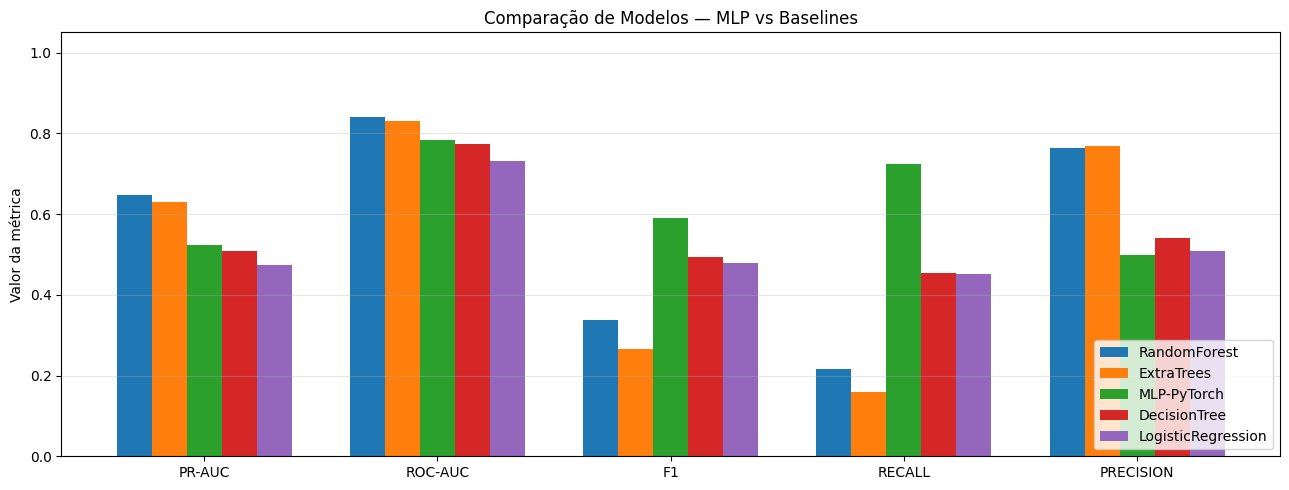

Figura salva: compare_models_bar.png


In [7]:
# --- Gráfico de barras comparativo ---
# Cada grupo de barras representa uma métrica; cada barra representa um modelo.
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(METRIC_COLS))
n_models = len(results_df)
width = 0.15  # Largura de cada barra
offsets = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[c] for c in METRIC_COLS]
    ax.bar(x + offsets[i], values, width, label=row["modelo"])

ax.set_xticks(x)
ax.set_xticklabels([m.upper().replace("_", "-") for m in METRIC_COLS])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor da métrica")
ax.set_title("Comparação de Modelos — MLP vs Baselines")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# --- Análise automática: quem ganhou em cada métrica ---
print("=== Análise: Melhor modelo por métrica ===\n")

for col in METRIC_COLS:
    best = results_df.loc[results_df[col].idxmax()]
    worst = results_df.loc[results_df[col].idxmin()]
    # margem sobre o segundo colocado
    segundo = results_df.loc[results_df["modelo"] != best["modelo"], col].max()
    gap = best[col] - segundo
    print(
        f"  {col.upper():12s}  →  Melhor: {best['modelo']:22s} ({best[col]:.4f})"
        f"  |  Pior: {worst['modelo']:22s} ({worst[col]:.4f})"
        f"  |  Margem s/ 2º: +{gap:.4f}"
    )

# Ranking de consistência: média das posições em cada métrica (1º = melhor)
rank_df = results_df[METRIC_COLS].rank(ascending=False).copy()
rank_df["modelo"] = results_df["modelo"].values
rank_df["rank_medio"] = rank_df[METRIC_COLS].mean(axis=1)
rank_df = rank_df.sort_values("rank_medio").reset_index(drop=True)

print("\n=== Ranking geral de consistência (menor rank médio = mais consistente) ===\n")
medals = ["1", "2", "3", "4", "5"]
for i, r in rank_df.iterrows():
    print(f"  {medals[i]}. rank médio {r['rank_medio']:.2f}  ->  {r['modelo']}")

melhor = rank_df.iloc[0]["modelo"]
print(f"\nModelo mais consistente no conjunto de teste: {melhor}")


=== Análise: Melhor modelo por métrica ===

  PR_AUC        →  Melhor: RandomForest           (0.6470)  |  Pior: LogisticRegression     (0.4732)  |  Margem s/ 2º: +0.0176
  ROC_AUC       →  Melhor: RandomForest           (0.8402)  |  Pior: LogisticRegression     (0.7321)  |  Margem s/ 2º: +0.0108
  F1            →  Melhor: MLP-PyTorch            (0.5911)  |  Pior: ExtraTrees             (0.2655)  |  Margem s/ 2º: +0.0969
  RECALL        →  Melhor: MLP-PyTorch            (0.7246)  |  Pior: ExtraTrees             (0.1604)  |  Margem s/ 2º: +0.2701
  PRECISION     →  Melhor: ExtraTrees             (0.7692)  |  Pior: MLP-PyTorch            (0.4991)  |  Margem s/ 2º: +0.0051

=== Ranking geral de consistência (menor rank médio = mais consistente) ===

  1. rank médio 2.40  ->  RandomForest
  2. rank médio 2.60  ->  MLP-PyTorch
  3. rank médio 3.00  ->  ExtraTrees
  4. rank médio 3.00  ->  DecisionTree
  5. rank médio 4.00  ->  LogisticRegression

Modelo mais consistente no conjunto de teste

## Etapa 6 — Registro consolidado no MLflow (item 5)

Esta etapa registra **todos os modelos comparados** (lineares, árvores/ensembles e MLP) em um experimento único do MLflow para auditoria e reprodução.

Saídas desta etapa:
- `run_id` por modelo.
- `model_uri` por modelo.
- parâmetros e métricas no tracking.
- arquivo resumo `mlflow_resumo_experimentos_etapa2.csv`.

In [ ]:
import mlflow.sklearn

EXPERIMENTO_CONSOLIDADO = "Churn-Etapa2-Comparacao-Modelos"
mlflow.set_experiment(EXPERIMENTO_CONSOLIDADO)

# Constrói mapa rápido de métricas já calculadas na Etapa 5 final.
metrics_map = {
    row["modelo"]: {
        "pr_auc": float(row["pr_auc"]),
        "roc_auc": float(row["roc_auc"]),
        "f1": float(row["f1"]),
        "recall": float(row["recall"]),
        "precision": float(row["precision"]),
    }
    for _, row in results_df.iterrows()
}

# Seleciona apenas hiperparâmetros importantes para manter o tracking legível.
def filtrar_params_modelo(params_dict):
    chaves_relevantes = {
        "max_iter", "random_state", "n_jobs",
        "max_depth", "n_estimators", "criterion", "min_samples_split", "min_samples_leaf"
    }
    return {
        k: str(v)
        for k, v in params_dict.items()
        if k in chaves_relevantes
    }

registros_mlflow = []

# Registra modelos sklearn (lineares + árvore + ensembles).
for nome_modelo, modelo in sklearn_models.items():
    run_name = f"05_compare_{nome_modelo}"
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tags({
            "etapa": "2",
            "notebook_origem": "05_compare_mlp_baselines.ipynb",
            "familia": "sklearn",
            "modelo": nome_modelo,
        })

        params_modelo = filtrar_params_modelo(modelo.get_params())
        if params_modelo:
            mlflow.log_params(params_modelo)

        for metrica, valor in metrics_map[nome_modelo].items():
            mlflow.log_metric(metrica, valor)

        mlflow.sklearn.log_model(modelo, name="model")

        registros_mlflow.append({
            "modelo": nome_modelo,
            "familia": "sklearn",
            "run_id": run.info.run_id,
            "model_uri": f"runs:/{run.info.run_id}/model",
            **metrics_map[nome_modelo],
        })

# Registra a MLP no mesmo experimento consolidado.
nome_mlp = "MLP-PyTorch"
with mlflow.start_run(run_name="05_compare_MLP-PyTorch") as run:
    mlflow.set_tags({
        "etapa": "2",
        "notebook_origem": "05_compare_mlp_baselines.ipynb",
        "familia": "pytorch",
        "modelo": nome_mlp,
        "mlp_run_origem_notebook04": str(MLP_RUN_ID),
    })

    mlflow.log_param("batch_size_inferencia", BATCH_SIZE)
    mlflow.log_param("device", str(DEVICE))
    mlflow.log_param("mlp_threshold_padrao", 0.5)
    mlflow.log_param("mlp_threshold_otimo_f1_validacao", THRESHOLD_MLP_OTIMO)

    # Guarda também comparação da MLP antes/depois da calibração para auditoria.
    mlflow.log_metric("mlp_f1_threshold_050", float(mlp_050_row["f1"]))
    mlflow.log_metric("mlp_recall_threshold_050", float(mlp_050_row["recall"]))
    mlflow.log_metric("mlp_precision_threshold_050", float(mlp_050_row["precision"]))

    for metrica, valor in metrics_map[nome_mlp].items():
        mlflow.log_metric(metrica, valor)

    mlflow.pytorch.log_model(mlp_model, name="model")

    registros_mlflow.append({
        "modelo": nome_mlp,
        "familia": "pytorch",
        "run_id": run.info.run_id,
        "model_uri": f"runs:/{run.info.run_id}/model",
        **metrics_map[nome_mlp],
    })

# Consolidado final para auditoria.
mlflow_resumo_df = pd.DataFrame(registros_mlflow).sort_values("pr_auc", ascending=False).reset_index(drop=True)

print(f"Experimento consolidado: {EXPERIMENTO_CONSOLIDADO}")
display(mlflow_resumo_df)

2026/04/13 21:01:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 21:01:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/13 21:02:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

Experimento consolidado: Churn-Etapa2-Comparacao-Modelos
Arquivo salvo: mlflow_resumo_experimentos_etapa2.csv


,modelo,familia,run_id,model_uri,pr_auc,roc_auc,f1,recall,precision
0,RandomForest,sklearn,7b5f5a311ae3495881e67365c10b66c1,runs:/7b5f5a311ae3495881e67365c10b66c1/model,0.647034,0.840172,0.337500,0.216578,0.764151
1,ExtraTrees,sklearn,bacdb37c98174d7ca8a169d8bd57b336,runs:/bacdb37c98174d7ca8a169d8bd57b336/model,0.629469,0.829376,0.265487,0.160428,0.769231
2,MLP-PyTorch,pytorch,63e6a15ea3884901975d853d883cbb2d,runs:/63e6a15ea3884901975d853d883cbb2d/model,0.523736,0.784342,0.591058,0.724599,0.499079
3,DecisionTree,sklearn,15f13b63f39d4c21952e8711570c7ef1,runs:/15f13b63f39d4c21952e8711570c7ef1/model,0.507900,0.773615,0.494186,0.454545,0.541401
4,LogisticRegression,sklearn,c89b783c26394f139a593ab41d48f40a,runs:/c89b783c26394f139a593ab41d48f40a/model,0.473207,0.732111,0.478076,0.451872,0.507508


## Resumo e conexão com o próximo notebook

### O que foi feito

| Modelo | Família | Observação |
|---|---|---|
| Regressão Logística | Linear | Baseline forte e interpretável |
| Árvore de Decisão | Não-linear | Interpretável, mas tende a overfitting |
| Random Forest | Ensemble | Reduz variância da árvore única |
| Extra Trees | Ensemble | Splits aleatórios → mais diversidade |
| MLP PyTorch | Rede neural | Captura interações não-lineares complexas |

### Próximo notebook: `06_tradeoff_custo_fp_fn.ipynb`

Com o **melhor modelo identificado aqui**, o próximo notebook aprofunda:
- Análise de custo FP vs FN usando o CLTV real dos clientes.
- Varredura de thresholds para maximizar lucro líquido.
- Escolha do threshold de produção alinhado ao negócio.

> **Como conectar**: pegue o nome do modelo vencedor pela coluna `pr_auc` do `results_df`
> e carregue-o via `mlflow.sklearn.load_model()` ou `mlflow.pytorch.load_model()`
> no notebook 06, usando o `run_id` exibido no print acima.